Importing the needed Libraries
using the tiny llama because of the hardware bottle neck

In [ ]:
import torch
import time
# from google.colab import userdata
from transformers import AutoModelForCausalLM, AutoTokenizer

In [2]:
# os.environ["HF_TOKEN"] = userdata.get('HF_Token')
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# 2. Load tokenizer and model with the config and device map
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto" # This automatically handles pushing it to GPU
)

Loading weights: 100%|██████████| 201/201 [00:01<00:00, 120.41it/s]


In [3]:
short_prompt = "What is the capital of France?"

medium_prompt = "Write a short story about a robot who discovers music. The robot, Unit 734, had only ever known logic and efficiency. One day, it stumbles upon an old, forgotten record player. Describe its first experience listening to a classical music piece and how it changed its perception of the world."

long_prompt = """Please summarize the following political argument:

First Citizen: We are accounted poor citizens, the patricians good. What authority surfeits on would relieve us: if they would yield us but the superfluity, while it were wholesome, we might guess they relieved us humanely; but they think we are too dear: the leanness that afflicts us, the object of our misery, is as an inventory to particularise their abundance; our sufferance is a gain to them. Let us revenge this with our pikes, ere we become rakes: for the gods know I speak this in hunger for bread, not in thirst for revenge.

Second Citizen: Would you proceed especially against Caius Marcius?

All: Against him first: he's a very dog to the commonalty.

Second Citizen: Consider you what services he has done for his country?

First Citizen: Very well; and could be content to give him good report for't, but that he pays himself with being proud.

Second Citizen: Nay, but speak not maliciously.

First Citizen: I say unto you, what he hath done famously, he did it to that end: though soft-conscienced men can be content to say it was for his country, he did it to please his mother and to be partly proud; which he is, even till the altitude of his virtue.
"""
# Clean any residual memory overhead
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

prompts=[
    short_prompt,medium_prompt,long_prompt
]
x=[]
y=[]

print("Starting generation...")
start_time = time.perf_counter()

# Generate with explicit token limit constraints to maximize context size
for prompt in prompts:
    # Tokenize input
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,  # Forces a long generation sequence to stretch VRAM
            do_sample=True,
            temperature=0.7,
            eos_token_id=tokenizer.eos_token_id
        )

    end_time = time.perf_counter()

    # Calculate Performance Metrics
    generation_time = end_time - start_time
    tokens_generated = len(outputs[0]) - len(inputs.input_ids[0])
    tokens_per_sec = tokens_generated / generation_time

# Fetch Peak GPU Memory Allocation
    peak_vram = torch.cuda.max_memory_allocated("cuda") / (1024 ** 3) # Convert bytes to GB
    y.append([tokens_per_sec,peak_vram])
    print("\n--- BENCHMARK RESULTS ---")
    print(f"Tokens Generated: {tokens_generated}")
    print(f"Execution Time: {generation_time:.2f} seconds")
    print(f"Throughput: {tokens_per_sec:.2f} tokens/sec")
    print(f"Peak GPU VRAM Usage: {peak_vram:.2f} GB")

    # Print a portion of the text to confirm it worked
    print("\n--- SAMPLE OUTPUT ---")
    print(tokenizer.decode(outputs[0][:512], skip_special_tokens=True))

Starting generation...


[transformers] Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- BENCHMARK RESULTS ---
Tokens Generated: 1
Execution Time: 0.69 seconds
Throughput: 1.45 tokens/sec
Peak GPU VRAM Usage: 2.06 GB

--- SAMPLE OUTPUT ---
What is the capital of France?


[transformers] Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- BENCHMARK RESULTS ---
Tokens Generated: 20
Execution Time: 1.81 seconds
Throughput: 11.06 tokens/sec
Peak GPU VRAM Usage: 2.06 GB

--- SAMPLE OUTPUT ---
Write a short story about a robot who discovers music. The robot, Unit 734, had only ever known logic and efficiency. One day, it stumbles upon an old, forgotten record player. Describe its first experience listening to a classical music piece and how it changed its perception of the world. Use vivid and descriptive language to create a sense of wonder and curiosity in the reader.

--- BENCHMARK RESULTS ---
Tokens Generated: 512
Execution Time: 23.86 seconds
Throughput: 21.46 tokens/sec
Peak GPU VRAM Usage: 2.12 GB

--- SAMPLE OUTPUT ---
Please summarize the following political argument:

First Citizen: We are accounted poor citizens, the patricians good. What authority surfeits on would relieve us: if they would yield us but the superfluity, while it were wholesome, we might guess they relieved us humanely; but they think we are 

Now when FlashAttention-2 is enabled

In [4]:
import torch
import time
# from google.colab import userdata
from transformers import AutoModelForCausalLM, AutoTokenizer

In [5]:
# os.environ["HF_TOKEN"] = userdata.get('HF_Token')
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# 2. Load tokenizer and model with the config and device map
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto", # This automatically handles pushing it to GPU
    attn_implementation="flash_attention_2"
)

Loading weights: 100%|██████████| 201/201 [00:01<00:00, 106.48it/s]


In [6]:
short_prompt = "What is the capital of France?"

medium_prompt = "Write a short story about a robot who discovers music. The robot, Unit 734, had only ever known logic and efficiency. One day, it stumbles upon an old, forgotten record player. Describe its first experience listening to a classical music piece and how it changed its perception of the world."

long_prompt = """Please summarize the following political argument:

First Citizen: We are accounted poor citizens, the patricians good. 
What authority surfeits on would relieve us: if they would yield us but 
the superfluity, while it were wholesome, we might guess they relieved 
us humanely; but they think we are too dear: the leanness that afflicts
us, the object of our misery, is as an inventory to particularise their 
abundance; our sufferance is a gain to them. Let us revenge this with our
pikes, ere we become rakes: for the gods know I speak this in hunger
for bread, not in thirst for revenge.

Second Citizen: Would you proceed especially against Caius Marcius?

All: Against him first: he's a very dog to the commonalty.

Second Citizen: Consider you what services he has done for his country?

First Citizen: Very well; and could be content to give him good report for't, but that he pays himself with being proud.

Second Citizen: Nay, but speak not maliciously.

First Citizen: I say unto you, what he hath done famously, he did it to that end: though soft-conscienced men can be content to say it was for his country, he did it to please his mother and to be partly proud; which he is, even till the altitude of his virtue.
"""
# Clean any residual memory overhead
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print("Starting generation...")
start_time = time.perf_counter()
b=[]
# Generate with explicit token limit constraints to maximize context size
for prompt in prompts:
    # Tokenize input
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,  # Forces a long generation sequence to stretch VRAM
            do_sample=True,
            temperature=0.7,
            eos_token_id=tokenizer.eos_token_id
        )

    end_time = time.perf_counter()

    # Calculate Performance Metrics
    generation_time = end_time - start_time
    tokens_generated = len(outputs[0]) - len(inputs.input_ids[0])
    tokens_per_sec = tokens_generated / generation_time

    # Fetch Peak GPU Memory Allocation
    peak_vram = torch.cuda.max_memory_allocated("cuda") / (1024 ** 3) # Convert bytes to GB
    b.append([tokens_per_sec,peak_vram])
    print("\n--- BENCHMARK RESULTS ---")
    print(f"Tokens Generated: {tokens_generated}")
    print(f"Execution Time: {generation_time:.2f} seconds")
    print(f"Throughput: {tokens_per_sec:.2f} tokens/sec")
    print(f"Peak GPU VRAM Usage: {peak_vram:.2f} GB")

    # Print a portion of the text to confirm it worked
    print("\n--- SAMPLE OUTPUT ---")
    print(tokenizer.decode(outputs[0][:512], skip_special_tokens=True))

[transformers] Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Starting generation...


[transformers] Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- BENCHMARK RESULTS ---
Tokens Generated: 1
Execution Time: 0.24 seconds
Throughput: 4.24 tokens/sec
Peak GPU VRAM Usage: 2.06 GB

--- SAMPLE OUTPUT ---
What is the capital of France?


[transformers] Both `max_new_tokens` (=512) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- BENCHMARK RESULTS ---
Tokens Generated: 26
Execution Time: 2.09 seconds
Throughput: 12.45 tokens/sec
Peak GPU VRAM Usage: 2.06 GB

--- SAMPLE OUTPUT ---
Write a short story about a robot who discovers music. The robot, Unit 734, had only ever known logic and efficiency. One day, it stumbles upon an old, forgotten record player. Describe its first experience listening to a classical music piece and how it changed its perception of the world. Make sure to include vivid descriptions of the sounds and sights of Unit 734's discoveries.

--- BENCHMARK RESULTS ---
Tokens Generated: 512
Execution Time: 29.61 seconds
Throughput: 17.29 tokens/sec
Peak GPU VRAM Usage: 2.08 GB

--- SAMPLE OUTPUT ---
Please summarize the following political argument:

First Citizen: We are accounted poor citizens, the patricians good. What authority surfeits on would relieve us: if they would yield us but the superfluity, while it were wholesome, we might guess they relieved us humanely; but they think we are 

Generating the graph 

In [7]:
import matplotlib.pyplot as plt
import numpy as np

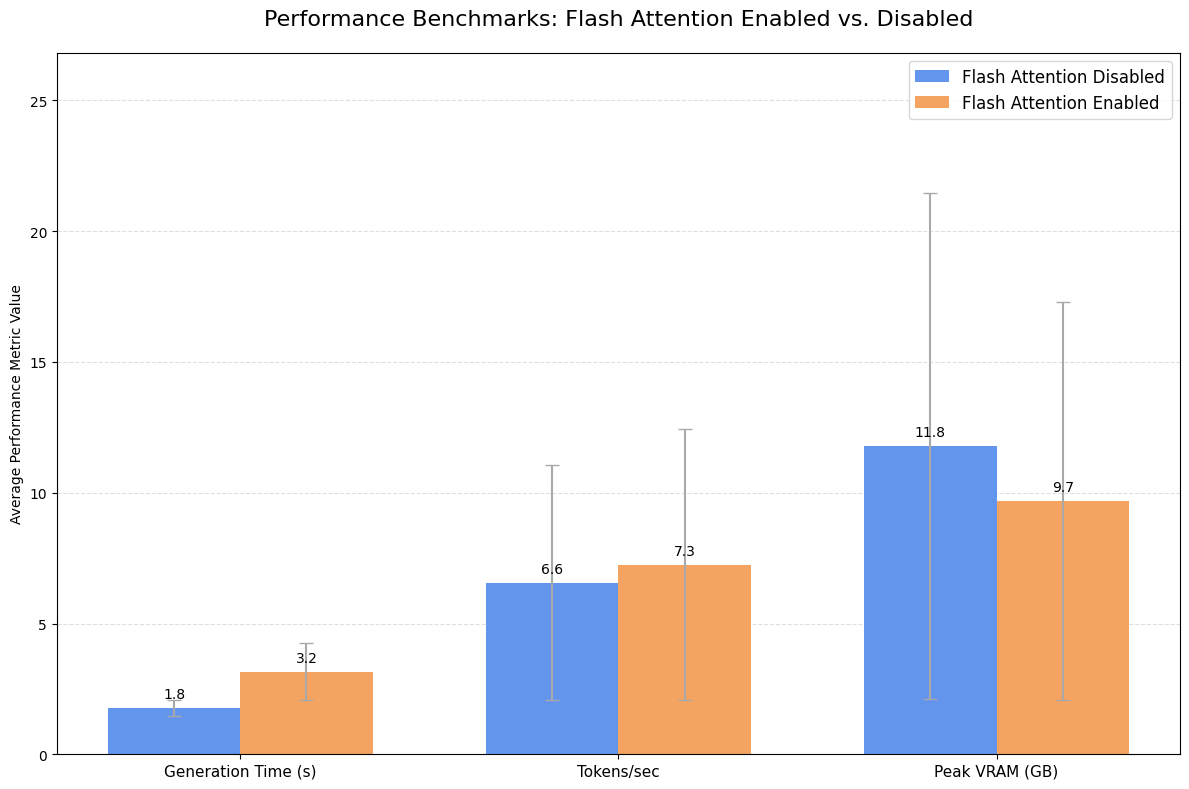

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Benchmark Categories ---
# This list now correctly has 3 items to match your 3 sets of collected data.
# If you collect more benchmarks later, you can add their names back here.
benchmarks = [
    'Generation Time (s)', 
    'Tokens/sec', 
    'Peak VRAM (GB)'
]

# --- 2. Process Your Existing Data ---
# The code below assumes 'y' and 'b' have been populated by your script.
# I've included a try-except block to handle cases where the script hasn't been run.
try:
    # This check will now pass because len(benchmarks) is 3 and len(y) is 3.
    if len(benchmarks) != len(y) or len(benchmarks) != len(b):
        print("--- PLOTTING ERROR ---")
        print(f"Error: Mismatch in data length. Your 'benchmarks' list has {len(benchmarks)} items, but your data lists have {len(y)} (disabled) and {len(b)} (enabled) items.")
        print("Solution: Please make sure the 'benchmarks' list in this cell exactly matches the number of benchmark categories you have collected.")
        y_means, b_means, y_std, b_std = ([0]*len(benchmarks), [0]*len(benchmarks), [0]*len(benchmarks), [0]*len(benchmarks))
    else:
        y_means = [np.mean(vals) for vals in y]
        b_means = [np.mean(vals) for vals in b]

        y_std = [np.std(vals) for vals in y]
        b_std = [np.std(vals) for vals in b]

except NameError:
    print("Error: The variables 'y' and 'b' were not found.")
    print("Please make sure you have run the cells that generate your benchmark data before this one.")
    y_means, b_means, y_std, b_std = ([0]*len(benchmarks), [0]*len(benchmarks), [0]*len(benchmarks), [0]*len(benchmarks))


# --- 3. Plotting Logic ---
x_pos = np.arange(len(benchmarks))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(12, 8))

# Plot the bars with error bars representing standard deviation.
rects1 = ax.bar(x_pos - bar_width/2, y_means, bar_width,
                label='Flash Attention Disabled', color='cornflowerblue',
                yerr=y_std, capsize=5, ecolor='darkgray')

rects2 = ax.bar(x_pos + bar_width/2, b_means, bar_width,
                label='Flash Attention Enabled', color='sandybrown',
                yerr=b_std, capsize=5, ecolor='darkgray')


# --- 4. Add Labels, Title, and Ticks ---
ax.set_ylabel('Average Performance Metric Value')
ax.set_title('Performance Benchmarks: Flash Attention Enabled vs. Disabled', fontsize=16, pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(benchmarks, fontsize=11)
ax.legend(fontsize=12)

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)
ax.set_axisbelow(True)

# Function to attach a text label above each bar.
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

# Add labels only if data exists.
if any(y_means) or any(b_means):
    autolabel(rects1)
    autolabel(rects2)

    # Adjust y-limit to make space for labels.
    max_y_val = max([m + s for m, s in zip(y_means, y_std)] + [m + s for m, s in zip(b_means, b_std)])
    ax.set_ylim(0, max_y_val * 1.25)

fig.tight_layout()
plt.show()
